In [35]:
# minimal example using LangChain's AzureChatOpenAI
from dotenv import load_dotenv
import os
from langchain_openai import AzureChatOpenAI
from typing import TypedDict
from langgraph.graph import StateGraph,START,END

load_dotenv()  # make sure your .env is loaded



True

In [201]:
class score_sate(TypedDict):
    runs    :int
    sixes    :int
    fours   :int
    balls   :int

    sr: float
    boundry_percentage : float
    bpb   : float
    summary : str
    

In [202]:
def cal_strike_rate(state : score_sate):
    sr = (state['runs']/state['balls'])*100
    # state['strikerate']=sr
    return {'sr':sr}

In [203]:
def boundry_percentage(state:score_sate):
    bp = (state['fours']*4 +state['sixes']*6)/state['runs']*100
    return {"boundry_percentage":bp}

In [204]:
def ball_perboundry(state:score_sate):
    bpb = state['balls']/(state['fours']+state['sixes'])
    return {'bpb':bpb}

In [206]:
def summary(state:score_sate):
    summary = f"""
Strike_rate - {state['sr']}\n
Balls per boundry - {state['bpb']}\n
Boundry percentage- {state['boundry_percentage']}
"""
    return {'summary' : summary}


In [207]:
graph =StateGraph(score_sate)

#add nodes
graph.add_node('calulate_strikeRate',cal_strike_rate)
graph.add_node('calulate_boundry_percentage',boundry_percentage)
graph.add_node('calculate_ball_perboundry',ball_perboundry)
graph.add_node('summary',summary)



#add edeges
graph.add_edge(START,'calulate_strikeRate')
graph.add_edge(START,'calulate_boundry_percentage')
graph.add_edge(START,'calculate_ball_perboundry')

graph.add_edge('calulate_strikeRate','summary')
graph.add_edge('calulate_boundry_percentage','summary')
graph.add_edge('calculate_ball_perboundry','summary')

graph.add_edge('summary',END)





#compile the graph
workflow = graph.compile()


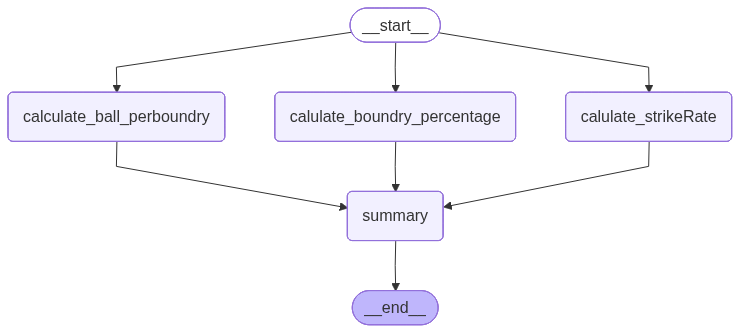

In [208]:
workflow

In [209]:
intial_state = {
    'runs': 100,
    'balls': 50,
    'fours': 6,
    'sixes': 4
}

workflow.invoke(intial_state)

{'runs': 100,
 'sixes': 4,
 'fours': 6,
 'balls': 50,
 'sr': 200.0,
 'boundry_percentage': 48.0,
 'bpb': 5.0,
 'summary': '\nStrike_rate - 200.0\n\nBalls per boundry - 5.0\n\nBoundry percentage- 48.0\n'}